Repeat the simulation as the previous assignment but using Wolff cluster algorithm.

Tasks: Plot the magnetization and energy as the function of $\beta$.

Compare Metropolis and Wolff cluster algorithm.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [12]:
def initial_config(N, start='random'):
    if start == 'cold':
        return np.full((N, N), -1)
    elif start == 'hot':
        return np.ones((N, N), dtype=int)
    else:
        return np.random.choice([-1, 1], size=(N, N))

In [13]:
def total_energy(grid):
    E = -np.sum(grid * np.roll(grid, 1, axis=0))
    E -= np.sum(grid * np.roll(grid, 1, axis=1))
    return E

In [14]:
def magnetization(grid):
    return np.abs(np.mean(grid))

## Wolff cluster step

In [15]:
def wolff_step(grid, beta):
    N = grid.shape[0]
    P_add = 1.0 - np.exp(-2.0 * beta)   # J = 1

    # pick a random seed spin
    i0, j0 = np.random.randint(0, N), np.random.randint(0, N)
    spin = grid[i0, j0]

    cluster = np.zeros((N, N), dtype=bool)
    cluster[i0, j0] = True
    queue = deque([(i0, j0)])

    while queue:
        i, j = queue.popleft()
        # check all 4 neighbours with periodic boundaries
        for ni, nj in [((i+1) % N, j), ((i-1) % N, j),
                        (i, (j+1) % N), (i, (j-1) % N)]:
            # only try neighbours with the same spin that are not yet in the cluster
            if grid[ni, nj] == spin and not cluster[ni, nj]:
                if np.random.rand() < P_add:
                    cluster[ni, nj] = True
                    queue.append((ni, nj))

    # flip the whole cluster
    grid[cluster] *= -1
    return grid

## Running the simulation

The structure is the same as in the Metropolis notebook:
burn-in first, then measurements.

In [16]:
N = 20
n_burn = 500
n_measure = 1000

beta_values = np.linspace(0.1, 0.9, 30)

mag_random  = []
mag_cold    = []
mag_hot     = []
energy_random = []

for beta in beta_values:
    # --- random start ---
    grid = initial_config(N, start='random')
    for _ in range(n_burn):
        grid = wolff_step(grid, beta)

    M_list, E_list = [], []
    for _ in range(n_measure):
        grid = wolff_step(grid, beta)
        M_list.append(magnetization(grid))
        E_list.append(total_energy(grid) / N**2)

    mag_random.append(np.mean(M_list))
    energy_random.append(np.mean(E_list))

    # --- cold start ---
    grid_c = initial_config(N, start='cold')
    for _ in range(n_burn):
        grid_c = wolff_step(grid_c, beta)
    mag_cold.append(np.mean([magnetization(wolff_step(grid_c, beta))
                              for _ in range(n_measure)]))

    # --- hot start ---
    grid_h = initial_config(N, start='hot')
    for _ in range(n_burn):
        grid_h = wolff_step(grid_h, beta)
    mag_hot.append(np.mean([magnetization(wolff_step(grid_h, beta))
                             for _ in range(n_measure)]))

print('Simulation done!')

Simulation done!


## Visualising the lattice

Let's look at the spin configurations at three different temperatures,
same as in the Metropolis notebook.

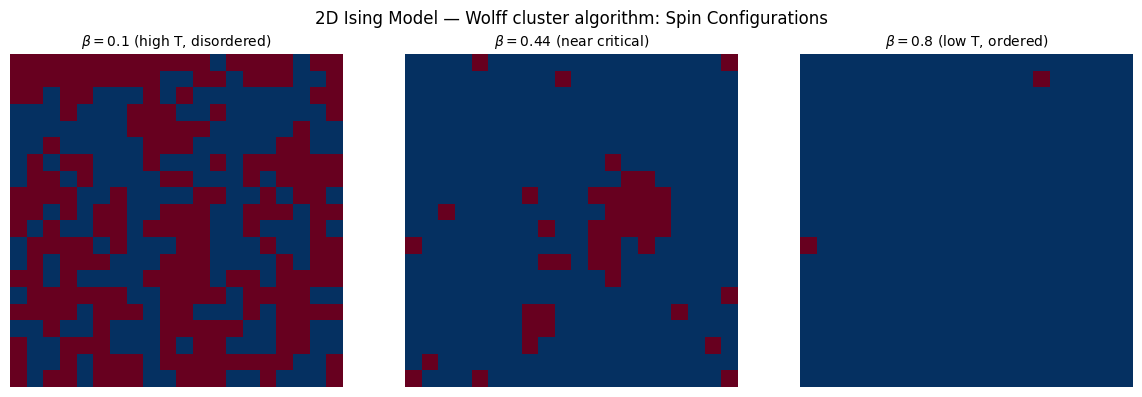

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
betas_to_show = [0.1, 0.44, 0.8]
titles = [r'$\beta = 0.1$ (high T, disordered)',
          r'$\beta = 0.44$ (near critical)',
          r'$\beta = 0.8$ (low T, ordered)']

for ax, b, title in zip(axes, betas_to_show, titles):
    g = initial_config(N, 'random')
    for _ in range(1000):
        g = wolff_step(g, b)
    ax.imshow(g, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('2D Ising Model — Wolff cluster algorithm: Spin Configurations', fontsize=12)
plt.tight_layout()
plt.savefig('wolff_ising_lattices.png', dpi=120)
plt.show()

## Magnetization and Energy vs $\\beta$

Same plots as in the Metropolis notebook.
The results are very similar.

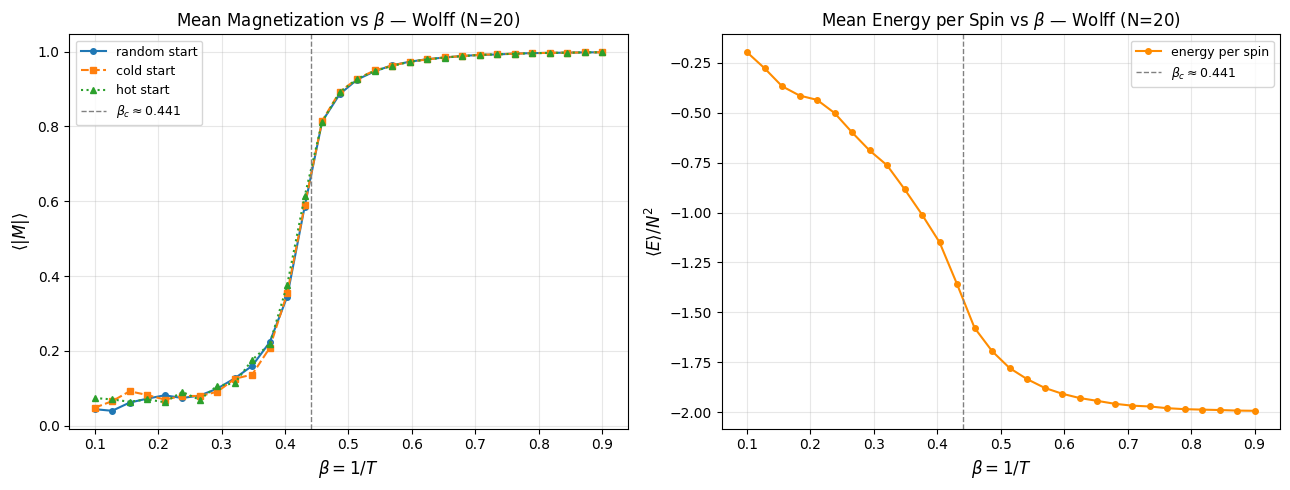

In [18]:
beta_c = np.log(1 + np.sqrt(2)) / 2   # critical beta

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- magnetization ---
ax = axes[0]
ax.plot(beta_values, mag_random, 'o-', label='random start', markersize=4)
ax.plot(beta_values, mag_cold,   's--', label='cold start',   markersize=4)
ax.plot(beta_values, mag_hot,    '^:', label='hot start',     markersize=4)
ax.axvline(beta_c, color='gray', linestyle='--', linewidth=1,
           label=rf'$\beta_c \approx {beta_c:.3f}$')
ax.set_xlabel(r'$\beta = 1/T$', fontsize=12)
ax.set_ylabel(r'$\langle |M| \rangle$', fontsize=12)
ax.set_title(f'Mean Magnetization vs $\\beta$ — Wolff (N={N})', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- energy ---
ax2 = axes[1]
ax2.plot(beta_values, energy_random, 'o-', color='darkorange',
         markersize=4, label='energy per spin')
ax2.axvline(beta_c, color='gray', linestyle='--', linewidth=1,
            label=rf'$\beta_c \approx {beta_c:.3f}$')
ax2.set_xlabel(r'$\beta = 1/T$', fontsize=12)
ax2.set_ylabel(r'$\langle E \rangle / N^2$', fontsize=12)
ax2.set_title(f'Mean Energy per Spin vs $\\beta$ — Wolff (N={N})', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wolff_ising_results.png', dpi=120)
plt.show()

## Comparison: Metropolis vs Wolff

To compare the two algorithms fairly, we run both from a random start
and measure how the magnetization evolves step-by-step
**at the critical temperature** $\\beta_c \\approx 0.44$.
This is where Metropolis suffers the most from critical slowing down.

In [19]:
def delta_energy(grid, i, j):
    N = grid.shape[0]
    s = (grid[(i+1) % N, j] + grid[(i-1) % N, j] +
         grid[i, (j+1) % N] + grid[i, (j-1) % N])
    return 2 * grid[i, j] * s

def metropolis_sweep(grid, beta):
    N = grid.shape[0]
    for _ in range(N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        dE = delta_energy(grid, i, j)
        if dE <= 0:
            grid[i, j] *= -1
        elif np.random.rand() < np.exp(-beta * dE):
            grid[i, j] *= -1
    return grid

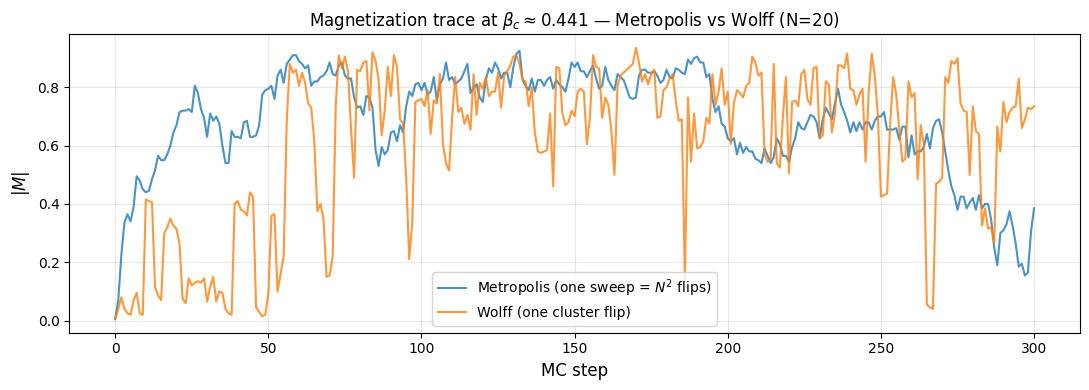

In [20]:
# Run both algorithms 

n_steps = 300
beta_test = beta_c

np.random.seed(42)
grid0 = initial_config(N, 'random')

# Metropolis
grid_met = grid0.copy()
mag_met_trace = [magnetization(grid_met)]
for _ in range(n_steps):
    grid_met = metropolis_sweep(grid_met, beta_test)
    mag_met_trace.append(magnetization(grid_met))

# Wolff
grid_wlf = grid0.copy()
mag_wlf_trace = [magnetization(grid_wlf)]
for _ in range(n_steps):
    grid_wlf = wolff_step(grid_wlf, beta_test)
    mag_wlf_trace.append(magnetization(grid_wlf))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mag_met_trace, alpha=0.8, label='Metropolis (one sweep = $N^2$ flips)')
ax.plot(mag_wlf_trace, alpha=0.8, label='Wolff (one cluster flip)')
ax.set_xlabel('MC step', fontsize=12)
ax.set_ylabel(r'$|M|$', fontsize=12)
ax.set_title(rf'Magnetization trace at $\beta_c \approx {beta_c:.3f}$ — Metropolis vs Wolff (N={N})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wolff_vs_metropolis_trace.png', dpi=120)
plt.show()

The Wolff trace makes larger, more sudden jumps, meaning it explores the configuration space more aggressively in a single step.

The Metropolis trace changes more gradually, since it only flips one spin at a time.